In [4]:
from datascience import *
path_data = 'data/'
import numpy as np
import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
np.set_printoptions(legacy='1.13')

In [5]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 진짜 기울기에 대한 추론

우리의 시뮬레이션은 회귀 모델이 성립하고 표본 크기가 크면, 회귀선은 진짜 선에 가까울 가능성이 높다는 것을 보여줍니다. 이를 통해 진짜 선의 기울기를 추정할 수 있습니다.

우리는 친숙한 산모와 신생아 표본을 사용하여 진짜 선의 기울기를 추정하는 방법을 개발할 것입니다. 먼저, 회귀 모델이 출생 체중과 재태 기간 일수 간의 관계를 설명하기에 적절한 가정 집합인지 믿을 수 있는지 살펴봅시다.

In [6]:
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)

def correlation(t, x, y):
    return np.mean(standard_units(t.column(x))*standard_units(t.column(y)))

def slope(table, x, y):
    r = correlation(table, x, y)
    return r * np.std(table.column(y))/np.std(table.column(x))

def intercept(table, x, y):
    a = slope(table, x, y)
    return np.mean(table.column(y)) - a * np.mean(table.column(x))

def fit(table, x, y):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

def residual(table, x, y):
    return table.column(y) - fit(table, x, y)

def scatter_fit(table, x, y):
    plots.scatter(table.column(x), table.column(y), s=20)
    plots.plot(table.column(x), fit(table, x, y), lw=2, color='gold')
    plots.xlabel(x)
    plots.ylabel(y)

In [7]:
def draw_and_compare(true_slope, true_int, sample_size):
    x = np.random.normal(50, 5, sample_size)
    xlims = np.array([np.min(x), np.max(x)])
    eps = np.random.normal(0, 6, sample_size)
    y = (true_slope*x + true_int) + eps
    tyche = Table().with_columns(
        'x', x,
        'y', y
    )

    plots.figure(figsize=(6, 16))
    plots.subplot(4, 1, 1)
    plots.scatter(tyche['x'], tyche['y'], s=20)
    plots.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plots.title('True Line, and Points Created')

    plots.subplot(4, 1, 2)
    plots.scatter(tyche['x'],tyche['y'], s=20)
    plots.title('What We Get to See')

    plots.subplot(4, 1, 3)
    scatter_fit(tyche, 'x', 'y')
    plots.xlabel("")
    plots.ylabel("")
    plots.title('Regression Line: Estimate of True Line')

    plots.subplot(4, 1, 4)
    scatter_fit(tyche, 'x', 'y')
    plots.ylabel("")
    xlims = np.array([np.min(tyche['x']), np.max(tyche['x'])])
    plots.plot(xlims, true_slope*xlims + true_int, lw=2, color='green')
    plots.title("Regression Line and True Line")

In [8]:
baby = Table.read_table(path_data + 'baby.csv')

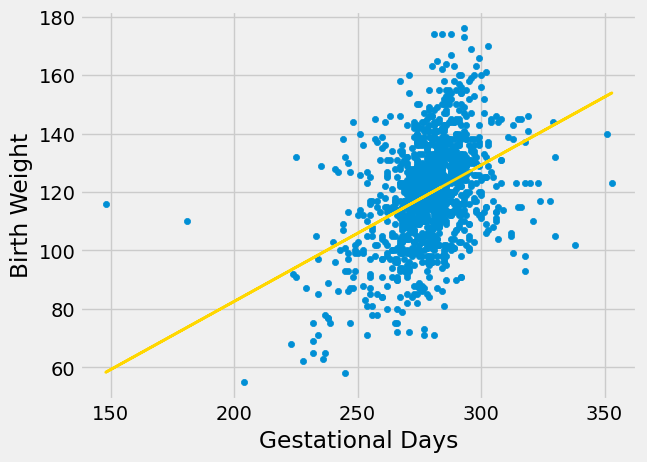

In [9]:
scatter_fit(baby, 'Gestational Days', 'Birth Weight')

In [10]:
correlation(baby, 'Gestational Days', 'Birth Weight')

0.40754279338885108

대체로 산점도는 선 주위에 상당히 고르게 분포되어 있지만, 주 클라우드의 외곽에 흩어져 있는 몇몇 점들이 있습니다. 상관관계는 0.4이고 회귀선은 양의 기울기를 가집니다.

이것이 진짜 선이 양의 기울기를 가진다는 사실을 반영할까요? 이 질문에 답하기 위해, 진짜 기울기를 추정할 수 있는지 살펴봅시다. 우리는 확실히 하나의 추정값을 가지고 있습니다: 회귀선의 기울기입니다. 그것은 하루당 약 0.47온스입니다.

In [11]:
slope(baby, 'Gestational Days', 'Birth Weight')

0.46655687694921522

그러나 산점도가 다르게 나왔다면, 회귀선은 달랐을 것이고 다른 기울기를 가졌을 수 있습니다. 기울기가 얼마나 달랐을 수 있었는지 어떻게 알아낼까요?

우리는 새로운 산점도를 통해 회귀선을 그리고 그 기울기를 찾을 수 있도록 다른 점들의 표본이 필요합니다. 그러나 어디서 다른 표본을 얻을까요?

당신이 짐작했듯이 – 우리는 *원래 표본을 부트스트랩*할 것입니다. 이것은 부트스트랩된 산점도를 제공할 것이고, 이를 통해 회귀선을 그릴 수 있습니다.

## 산점도 부트스트랩하기
원래 표본에서 복원 추출로 무작위 샘플링을 원래 표본 크기만큼 여러 번 수행하여 새로운 표본을 시뮬레이션할 수 있습니다. 이러한 새로운 표본 각각은 산점도를 제공할 것입니다. 우리는 이것을 *부트스트랩된 산점도(bootstrapped scatter plot)*라고 부를 것이고, 간단히 말해서 전체 과정을 *산점도 부트스트랩하기(bootstrapping the scatter plot)*라고 부를 것입니다.

다음은 표본의 원래 산점도와 부트스트랩 재샘플링 절차의 네 번의 반복입니다. 재샘플링된 산점도가 일반적으로 원본보다 조금 더 희소한 것을 주목하세요. 이는 원본 점 중 일부가 표본에 선택되지 않기 때문입니다.

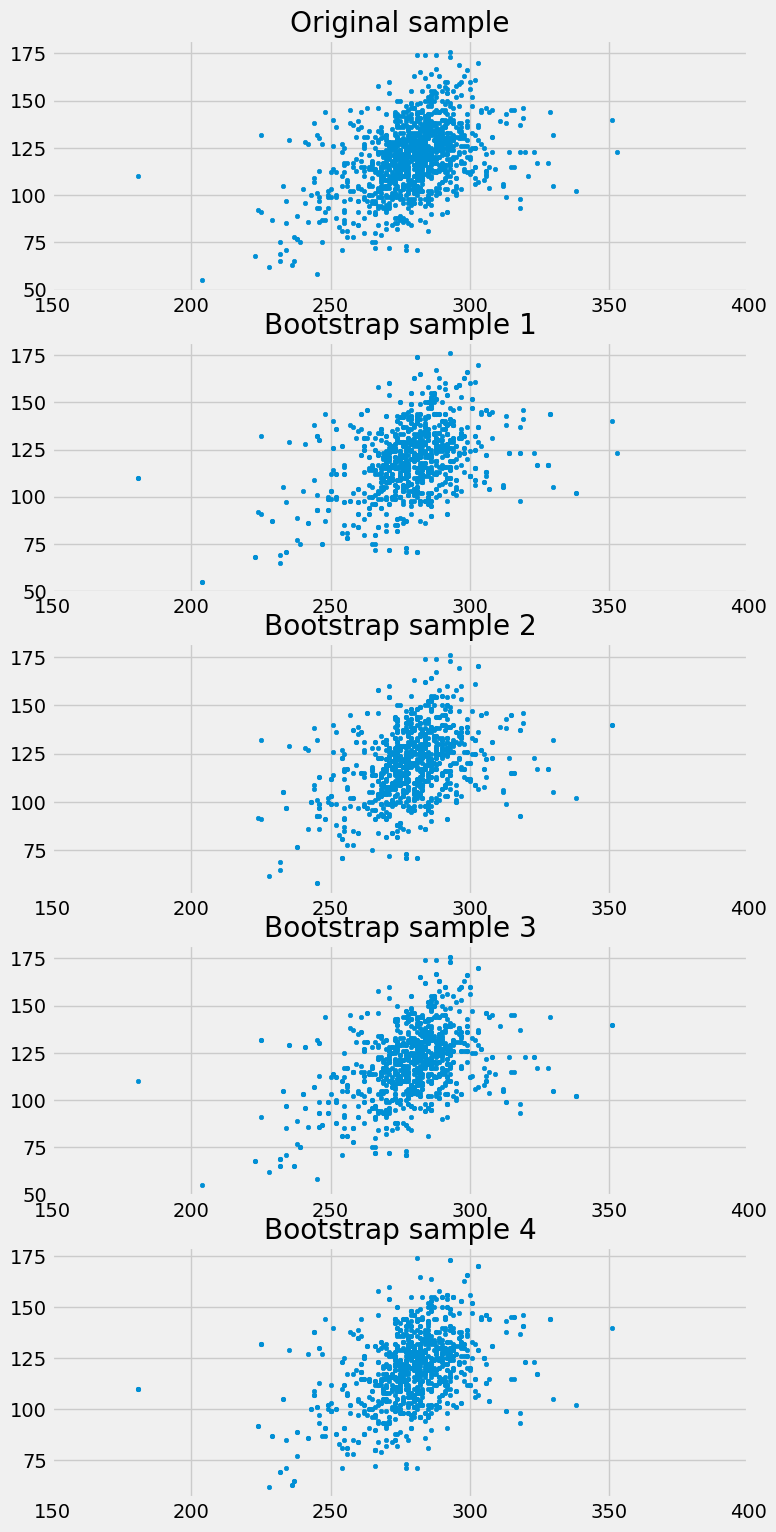

In [12]:
plots.figure(figsize=(8, 18))
plots.subplot(5, 1, 1)
plots.scatter(baby[1], baby[0], s=10)
plots.xlim([150, 400])
plots.title('Original sample')

for i in np.arange(1, 5, 1):
    plots.subplot(5,1,i+1)
    rep = baby.sample(with_replacement=True)
    plots.scatter(rep[1], rep[0], s=10)
    plots.xlim([150, 400])
    plots.title('Bootstrap sample '+str(i))

## 진짜 기울기 추정하기

산점도를 여러 번 부트스트랩하고, 각 부트스트랩된 플롯을 통해 회귀선을 그릴 수 있습니다. 이러한 선 각각은 기울기를 가집니다. 우리는 단순히 모든 기울기를 수집하고 그들의 경험적 히스토그램을 그릴 수 있습니다. 기본적으로 `sample` 메서드는 테이블의 행 수만큼 복원 추출로 무작위로 추출한다는 것을 기억하세요. 즉, `sample`은 기본적으로 부트스트랩 표본을 생성합니다.

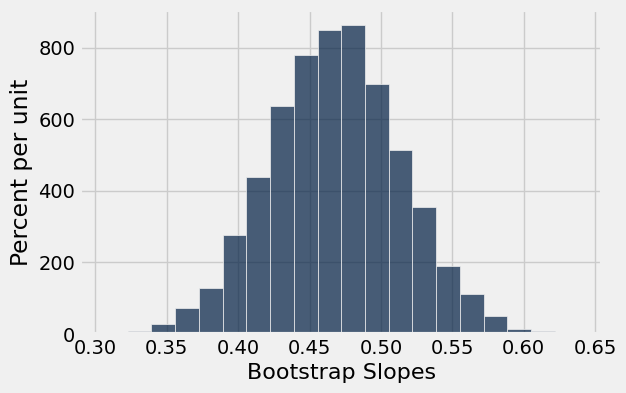

In [13]:
slopes = make_array()
for i in np.arange(5000):
    bootstrap_sample = baby.sample()
    bootstrap_slope = slope(bootstrap_sample, 'Gestational Days', 'Birth Weight')
    slopes = np.append(slopes, bootstrap_slope)
Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)

그런 다음 부트스트랩 백분위수 방법을 사용하여 진짜 선의 기울기에 대한 근사 95% 신뢰구간을 구성할 수 있습니다. 신뢰구간은 5000개의 부트스트랩된 기울기의 2.5번째 백분위수에서 97.5번째 백분위수까지 확장됩니다.

In [14]:
left = percentile(2.5, slopes)
right = percentile(97.5, slopes)
left, right

(0.37952740562583315, 0.5576015649007241)

진짜 기울기에 대한 근사 95% 신뢰구간은 하루당 약 0.38온스에서 하루당 약 0.56온스까지 확장됩니다.

## 기울기를 부트스트랩하는 함수

기울기를 추정하는 우리 방법의 모든 단계를 수집하고, 이를 수행하는 `bootstrap_slope` 함수를 정의합시다. 이 함수의 인수는 테이블의 이름, 예측 변수와 반응 변수의 레이블, 그리고 원하는 부트스트랩 반복 횟수입니다. 각 반복에서, 함수는 원래 산점도를 부트스트랩하고 결과 회귀선의 기울기를 계산합니다. 그런 다음 생성된 모든 기울기의 히스토그램을 그리고 기울기의 "중간 95%"로 구성된 구간을 출력합니다.

In [15]:
def bootstrap_slope(table, x, y, repetitions):

    # For each repetition:
    # Bootstrap the scatter, get the slope of the regression line,
    # augment the list of generated slopes
    slopes = make_array()
    for i in np.arange(repetitions):
        bootstrap_sample = table.sample()
        bootstrap_slope = slope(bootstrap_sample, x, y)
        slopes = np.append(slopes, bootstrap_slope)

    # Find the endpoints of the 95% confidence interval for the true slope
    left = percentile(2.5, slopes)
    right = percentile(97.5, slopes)

    # Slope of the regression line from the original sample
    observed_slope = slope(table, x, y)

    # Display results
    Table().with_column('Bootstrap Slopes', slopes).hist(bins=20)
    plots.plot(make_array(left, right), make_array(0, 0), color='yellow', lw=8);
    print('Slope of regression line:', observed_slope)
    print('Approximate 95%-confidence interval for the true slope:')
    print(left, right)

반응 변수가 출생 체중이고 예측 변수가 재태 기간일 때 진짜 기울기에 대한 신뢰구간을 찾기 위해 `bootstrap_slope`를 호출하면, 이전에 얻은 것과 매우 가까운 구간을 얻습니다: 하루당 약 0.38온스에서 하루당 0.56온스까지.

Slope of regression line: 0.466556876949
Approximate 95%-confidence interval for the true slope:
0.380587068885 0.558240399572


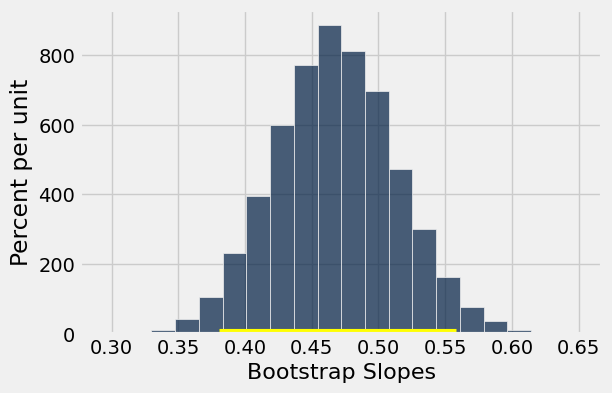

In [16]:
bootstrap_slope(baby, 'Gestational Days', 'Birth Weight', 5000)

이제 회귀 모델에서 진짜 선의 기울기를 추정하는 프로세스를 자동화하는 함수가 있으므로, 다른 변수에도 사용할 수 있습니다.

예를 들어, 출생 체중과 산모의 키 간의 관계를 살펴봅시다. 키가 큰 여성이 더 무거운 아기를 낳는 경향이 있을까요?

산점도를 기반으로 회귀 모델은 합리적으로 보이지만, 상관관계는 높지 않습니다. 약 0.2에 불과합니다.

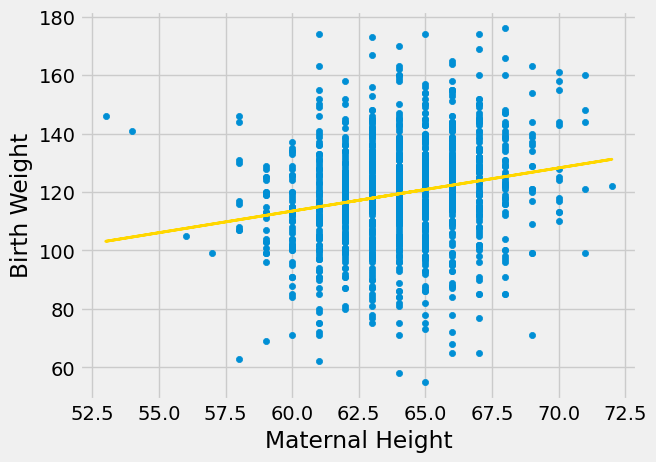

In [17]:
scatter_fit(baby, 'Maternal Height', 'Birth Weight')

In [18]:
correlation(baby, 'Maternal Height', 'Birth Weight')

0.20370417718968034

이전과 같이, `bootstrap_slope`를 사용하여 회귀 모델에서 진짜 선의 기울기를 추정할 수 있습니다.

Slope of regression line: 1.47801935193
Approximate 95%-confidence interval for the true slope:
1.05651080238 1.9012152781


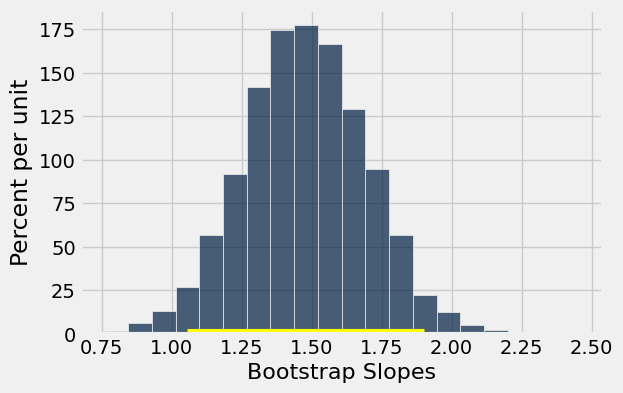

In [19]:
bootstrap_slope(baby, 'Maternal Height', 'Birth Weight', 5000)

진짜 기울기에 대한 95% 신뢰구간은 인치당 약 1온스에서 인치당 약 1.9온스까지 확장됩니다.

## 진짜 기울기가 0일 수 있을까?

우리 데이터가 회귀 모델을 따른다고 믿고, 진짜 선을 추정하기 위해 회귀선을 적합시킨다고 가정해 봅시다. 거의 예외 없이 그렇듯이 회귀선이 완전히 평평하지 않다면, 산점도에서 어느 정도의 선형 연관성을 관찰하게 될 것입니다.

그러나 그 관찰이 가짜라면 어떻게 될까요? 즉, 진짜 선이 평평했다면 – 즉, 두 변수 간에 선형 관계가 없었다면 – 우리가 관찰한 연관성이 표본을 구성하는 점들을 생성하는 무작위성 때문일 뿐이라면 어떻게 될까요?

다음은 이 질문이 왜 발생하는지 보여주는 시뮬레이션입니다. 우리는 ``draw_and_compare`` 함수를 다시 호출할 것인데, 이번에는 진짜 선이 기울기 0을 갖도록 요구합니다. 우리의 목표는 회귀선이 0이 아닌 기울기를 보이는지 확인하는 것입니다.

``draw_and_compare`` 함수의 인수는 진짜 선의 기울기, 진짜 선의 절편, 그리고 생성될 점의 개수라는 것을 기억하세요.

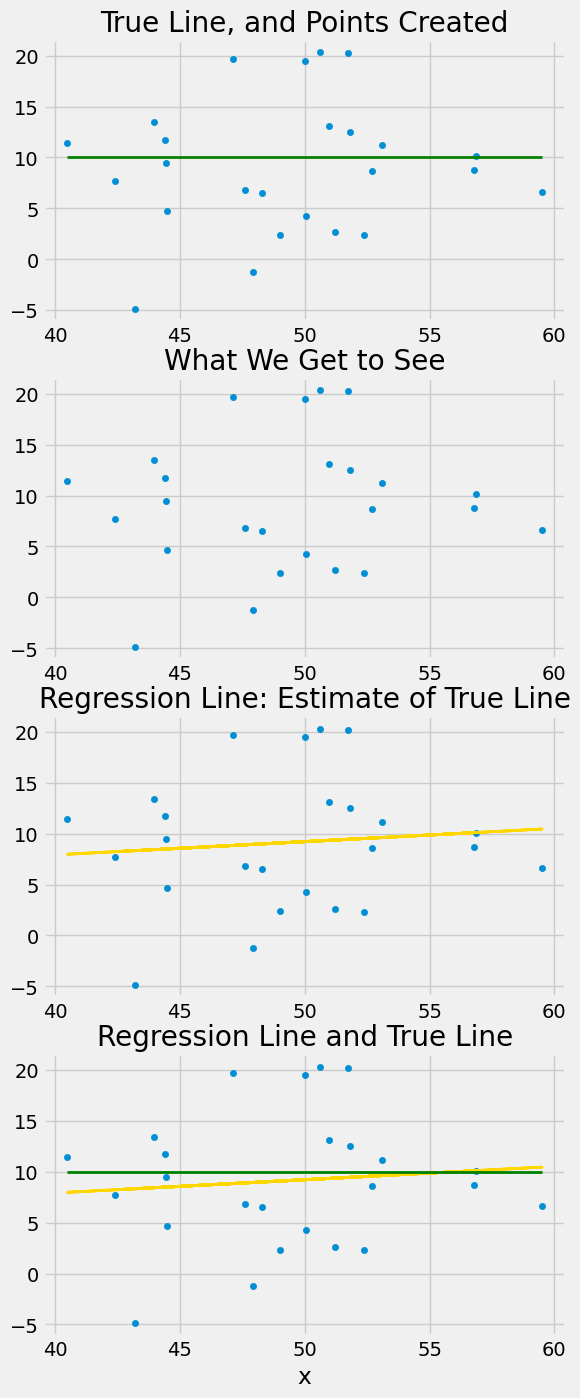

In [20]:
draw_and_compare(0, 10, 25)

진짜 선의 기울기를 매번 0으로 유지하면서 시뮬레이션을 몇 번 실행해 보세요. 진짜 선의 기울기가 0인 동안, 회귀선의 기울기는 일반적으로 0이 아니라는 것을 알게 될 것입니다. 회귀선은 때로는 위쪽으로, 때로는 아래쪽으로 기울어져, 매번 두 변수가 상관관계가 있다는 잘못된 인상을 줍니다.

우리가 보고 있는 기울기가 실제인지 여부를 결정하기 위해, 다음 가설을 검정하고자 합니다:

**귀무가설.** 진짜 선의 기울기는 0이다.

**대립가설.** 진짜 선의 기울기는 0이 아니다.

우리는 이것을 수행할 수 있는 좋은 위치에 있습니다. 진짜 기울기에 대한 95% 신뢰구간을 구성할 수 있으므로, 구간이 0을 포함하는지 확인하기만 하면 됩니다.

포함하지 않는다면, 귀무가설을 기각할 수 있습니다(P-값에 대한 5% 컷오프로).

진짜 기울기에 대한 신뢰구간이 0을 포함한다면, 귀무가설을 기각할 충분한 증거가 없습니다. 아마도 우리가 보고 있는 기울기는 가짜일 것입니다.

예제에서 이 방법을 사용해 봅시다. 산모의 나이를 기반으로 아기의 출생 체중을 추정하려고 한다고 가정해 봅시다. 표본을 기반으로, 모성 나이를 기반으로 출생 체중을 추정하는 회귀선의 기울기는 양수이며, 년당 약 0.08온스입니다.

In [21]:
slope(baby, 'Maternal Age', 'Birth Weight')

0.085007669415825132

기울기가 양수이긴 하지만 매우 작습니다. 회귀선이 너무 평평에 가까워서 진짜 선이 평평한지 의문이 제기됩니다.

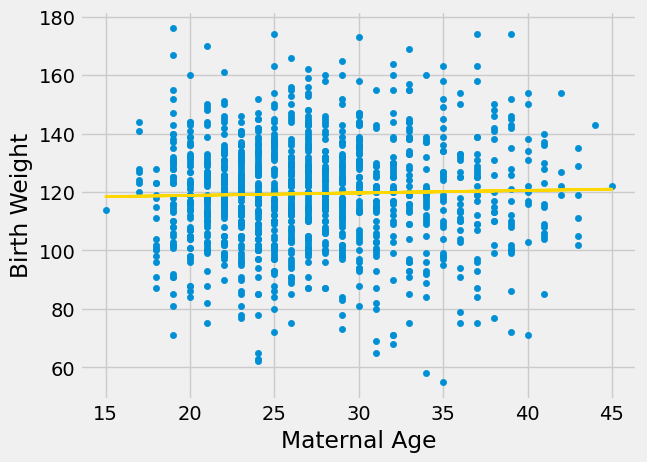

In [22]:
scatter_fit(baby, 'Maternal Age', 'Birth Weight')

`bootstrap_slope`를 사용하여 진짜 선의 기울기를 추정할 수 있습니다. 계산 결과 진짜 기울기에 대한 근사 95% 부트스트랩 신뢰구간은 왼쪽 끝점이 음수이고 오른쪽 끝점이 양수입니다 – 즉, 구간이 0을 포함합니다.

Slope of regression line: 0.0850076694158
Approximate 95%-confidence interval for the true slope:
-0.101424647973 0.268619059679


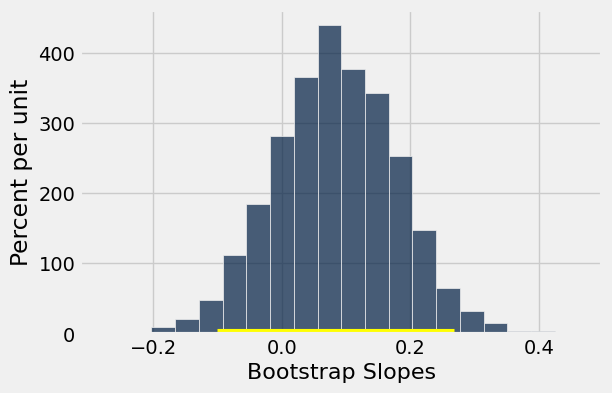

In [23]:
bootstrap_slope(baby, 'Maternal Age', 'Birth Weight', 5000)

구간이 0을 포함하므로, 모성 나이와 아기 출생 체중 간의 진짜 선형 관계의 기울기가 0이라는 귀무가설을 기각할 수 없습니다. 이 분석을 바탕으로, 모성 나이를 예측 변수로 하는 회귀 모델을 기반으로 출생 체중을 예측하는 것은 현명하지 않습니다.